In [1]:
import numpy as np
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
from topology import SimplicialComplex
from persistence import rips_filtration, PersistenceDiagram

### Rips complex in 2D

#### Layout

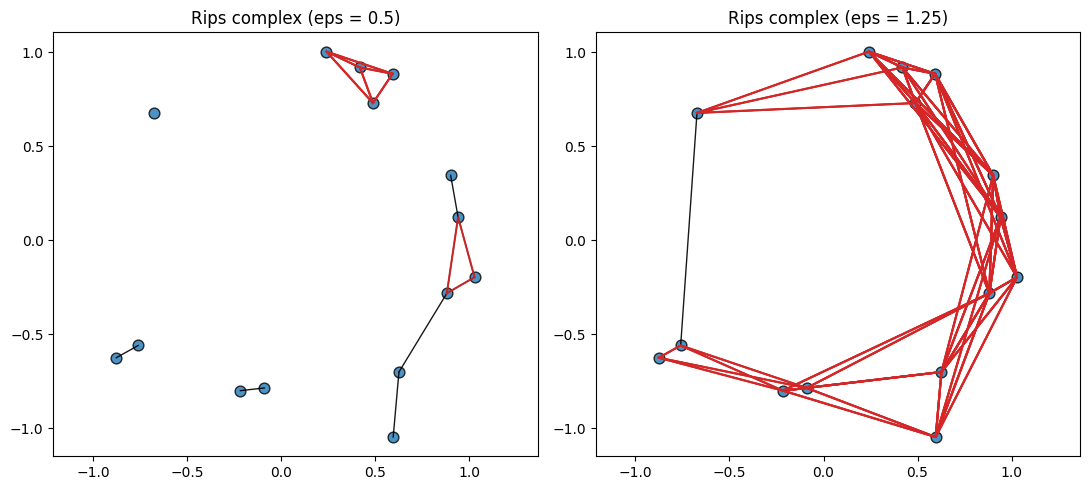

In [13]:
np.random.seed(42)

n_samples = 15
radius = 1.0
noise_level = 0.08

angles = np.random.uniform(0, 2 * np.pi, n_samples)
noise = np.random.normal(0, noise_level, n_samples)
noisy_radius = radius + noise

x = noisy_radius * np.cos(angles)
y = noisy_radius * np.sin(angles)

dataset = np.column_stack((x, y))


fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, eps in zip(axes, [0.5, 1.25]):

    complex = SimplicialComplex()
    rips = complex.rips_complex(dataset, eps)

    edges = rips.by_dim.get(1, [])
    triangles = rips.by_dim.get(2, [])

    ax.scatter(dataset[:, 0], dataset[:, 1],
               color=sns.color_palette()[0],
               s=60, edgecolor='black', alpha=0.8)

    ax.set_title(f"Rips complex (eps = {eps})")
    ax.axis('equal')
    ax.grid(False)

    for s in edges:
        i, j = s.vertices
        ax.plot([dataset[i, 0], dataset[j, 0]],
                [dataset[i, 1], dataset[j, 1]],
                color="black", alpha=0.9, linewidth=1)

    for s in triangles:
        i, j, k = s.vertices
        poly = dataset[[i, j, k, i]]
        ax.plot(poly[:, 0], poly[:, 1],
                color=sns.color_palette()[3], alpha=0.9)

plt.tight_layout()
plt.show()

Note the formation of a cycle when epsilon gets bigger. These finding are corroborated by a barcode diagram below.

#### Boundary matrix construction

In [3]:
print("Is boundary matrix well-defined:", complex.verify_boundary_property())
print(complex.boundary_matrix(1))

Is boundary matrix well-defined: True
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 1 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 1 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 1 0 0 0 1]]


#### Persistence comparison against ripser

[(0, 0.0, inf), (0, 0.0, 0.9710343404663414), (0, 0.0, 0.721554235998994), (0, 0.0, 0.5944476815597891), (0, 0.0, 0.5644763610950649), (0, 0.0, 0.18722574366265501), (0, 0.0, 0.33115685205950834), (0, 0.0, 0.4901545281009834), (0, 0.0, 0.1332082379753053), (0, 0.0, 0.1273347352129934), (0, 0.0, 0.22569370298462946), (0, 0.0, 0.17005856967513475), (0, 0.0, 0.3471229978599862), (0, 0.0, 0.1965841761801193), (0, 0.0, 0.1769320696165168), (1, 1.2398182034076852, 1.609607345194666)]


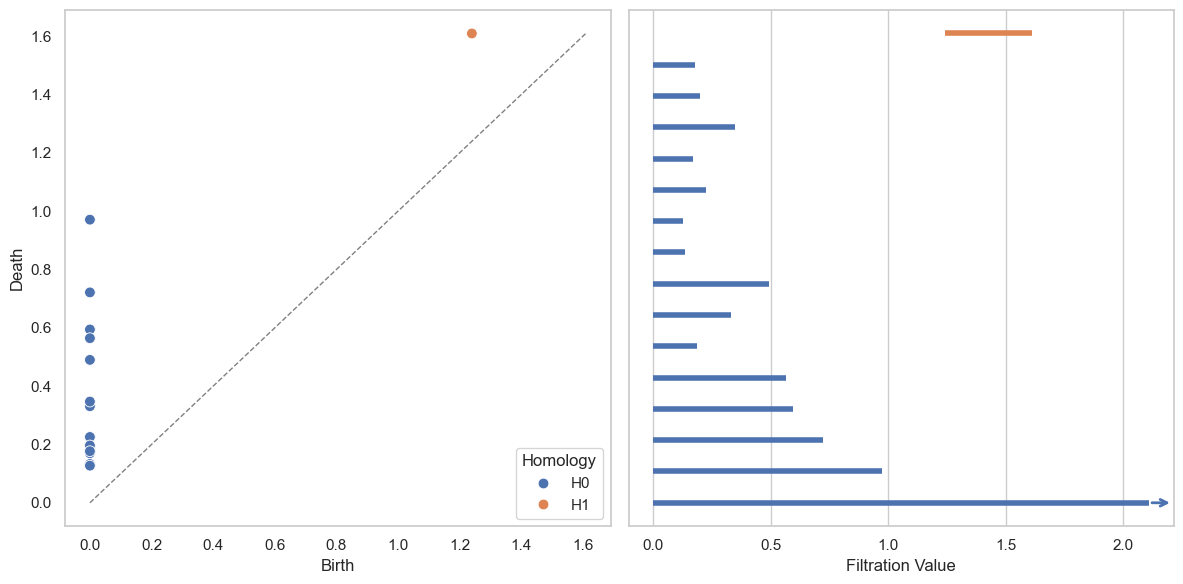

In [4]:
F = rips_filtration(dataset)
pairs = F.extract_pairs()

# Skip identical birth/death times and H2+
clean_pairs = []
for p in pairs:
    if p.birth == p.death:
        continue    
    if p.dim == 2:
        continue
    clean_pairs.append(p)

print(clean_pairs)


PD = PersistenceDiagram()
for pair in clean_pairs:
    PD.add_pair(pair)

PD.plot_diagram()

[[0.0, 0.12733472883701324], [0.0, 0.1332082450389862], [0.0, 0.17005856335163116], [0.0, 0.17693206667900085], [0.0, 0.18722574412822723], [0.0, 0.19658417999744415], [0.0, 0.2256937026977539], [0.0, 0.331156849861145], [0.0, 0.34712299704551697], [0.0, 0.49015453457832336], [0.0, 0.5644763708114624], [0.0, 0.594447672367096], [0.0, 0.7215542197227478], [0.0, 0.9710343480110168], [0.0, inf]] [[1.2398182153701782, 1.6096073389053345]]


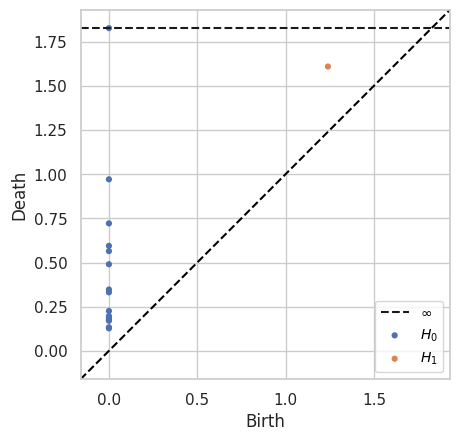

In [5]:
dgms = ripser(dataset)["dgms"]
print(dgms[0].tolist(), dgms[1].tolist())

plot_diagrams(dgms, show=True)

It is evident that the output of custom libraries matches that of ripser. We see one H1 feature being born / dying which indicates that the data structure is that of a noisy circle (which it is).